# Projekat klasifikacije fetalnog zdravlja

Cilj mog projekta je predvideti klasu zdravlja fetusa na osnovu CTG parametara. Klasifikacija se vrši u tri kategorije:
1.  **Normalno (Normal)**
2.  **Sumnjivo (Suspect)**
3.  **Patološko (Pathological)**


Podaci obuhvataju različite parametre izmerene tokom pregleda, uključujući:

*   **osnovnu frekvenciju srca (baseline value)**,
*   **ubrzanja (accelerations)**,
*   **pokrete fetusa (fetal movement)**,
*   **kontrakcije materice (uterine contractions)**,
*   **usporenja srca** (blaga, teška i produžena),
*   **varijabilnost** (kratkoročnu i dugoročnu),
*   **histogramske podatke** (širina, minimum, maksimum, mod, srednja vrednost, tendencija).

Smanjenje smrtnosti dece je jedan od ključnih ciljeva održivog razvoja Ujedinjenih nacija. CTG pregledi su jeftina i pristupačna opcija za procenu zdravlja, ali njihova interpretacija može biti subjektivna. Cilj ovog projekta je korišćenje mašinskog učenja za objektivniju i precizniju klasifikaciju zdravstvenog stanja fetusa.


Takođe, cilj je identifikovati **ključne faktore** (npr. produžena usporenja ili varijabilnost) koji najviše doprinose patološkom ishodu, kako bi se lekarima olakšalo donošenje odluka.

---


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [38]:

CSV_PATH = "fetal_health.csv" 

data = pd.read_csv(CSV_PATH) 

display(data.head()) 


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


Ova tabela pruža uvid u prvih 5 redova našeg skupa podataka, omogućavajući nam da vidimo strukturu i vrednosti različitih CTG parametara

In [39]:
# Prikaz informacija o strukturi podataka
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [40]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


## Analiza strukture podataka

- **Broj uzoraka (count):** Dataset sadrži ukupno 2126 unosa (redova). Za sve kolone, broj unosa je takođe 2126, što znači da nema nedostajućih vrednosti (Null). Ovo je odličan signal za konzistentnost podataka.

- **Tipovi podataka (Dtype):** Sve kolone su tipa `float64` (numeričke vrednosti), što je idealno za primenu mašinskog učenja i statističke analize.

In [41]:
# Prikaz osnovnih statistika sa transponovanim prikazom
transposed_stats = data.describe().T
transposed_stats

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


## Statistička analiza

- **Prosek (mean):** `baseline value` (FHR) ima prosečnu vrednost od oko 133 bpm, što je uobičajeno za zdrav fetus. Prosek za `fetal_health` je blizu 1, što ukazuje da je većina fetusa u zdravoj klasi (Klasa 1).

- **Standardna devijacija (std):** `histogram_width` ima visoku standardnu devijaciju, što ukazuje na značajnu varijabilnost u širini signala.

- **Min/Max:** `fetal_health` ima vrednosti u opsegu od 1 do 3.

- **Kvartili (25%, 50%, 75%):** Za `severe_decelerations` i `prolongued_decelerations`, 75% kvartil je i dalje 0, što implicira da su ovi opasni događaji retki i uglavnom predstavljaju outliere.

### Ključni zaključci:
- Nema nedostajućih vrednosti.
- Svi podaci su numerički.
- Klasa "Normal" (1) je dominantna, što ukazuje na nebalansiran skup podataka koji ćemo kasnije morati da rešimo (SMOTE).

## Čišćenje podataka

Proveravamo da li postoje duplikati.

In [42]:
# Provera i uklanjanje duplikata
print(f"Broj duplikata: {data.duplicated().sum()}")
if data.duplicated().sum() > 0:
    data = data.drop_duplicates()
print(f"Novi oblik podataka: {data.shape}")

Broj duplikata: 13
Novi oblik podataka: (2113, 22)


## Kodiranje podataka

Svi podaci su već numerički. Međutim, ciljna promenljiva 'fetal_health' je tipa float (1.0, 2.0, 3.0). Pretvorićemo je u integer (celobrojnu vrednost) radi lakšeg rada.


In [43]:
# Pretvaranje ciljne promenljive u integer
data['fetal_health'] = data['fetal_health'].astype(int)

# Provera promena u strukturi podataka
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2113 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2113 non-null   float64
 1   accelerations                                           2113 non-null   float64
 2   fetal_movement                                          2113 non-null   float64
 3   uterine_contractions                                    2113 non-null   float64
 4   light_decelerations                                     2113 non-null   float64
 5   severe_decelerations                                    2113 non-null   float64
 6   prolongued_decelerations                                2113 non-null   float64
 7   abnormal_short_term_variability                         2113 non-null   float64
 8   mean_value_of_short_term_variability       

In [44]:
# Prikaz osnovnih statistika
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,...,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
mean,133.304780,0.003188,0.009517,0.004387,0.001901,0.000003,0.000159,46.993848,1.335021,9.795078,...,93.564600,164.099858,4.077142,0.325603,137.454330,134.599621,138.089446,18.907241,0.318504,1.303833
std,9.837451,0.003871,0.046804,0.002941,0.002966,0.000057,0.000592,17.177782,0.884368,18.337073,...,29.562269,17.945175,2.951664,0.707771,16.402026,15.610422,14.478957,29.038766,0.611075,0.614279
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.005000,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,...,93.000000,162.000000,4.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.000000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.000000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


#  Eksploratorna analiza podataka (EDA)

 U ovom delu ćemo vizualizovati distribuciju klasa, analizirati korelacije između promenljivih i identifikovati potencijalne outliere.

Kreiranje grafikona za analizu distribucije podataka i odnosa između faktora rizika. Prvo ćemo proveriti balans klasa u ciljnoj promenljivoj 'fetal_health'.

In [45]:
# Prikaz broja uzoraka po klasama i njihovih procenata
print(data["fetal_health"].value_counts())
print(data["fetal_health"].value_counts(normalize=True) * 100)

fetal_health
1    1646
2     292
3     175
Name: count, dtype: int64
fetal_health
1    77.898722
2    13.819214
3     8.282063
Name: proportion, dtype: float64


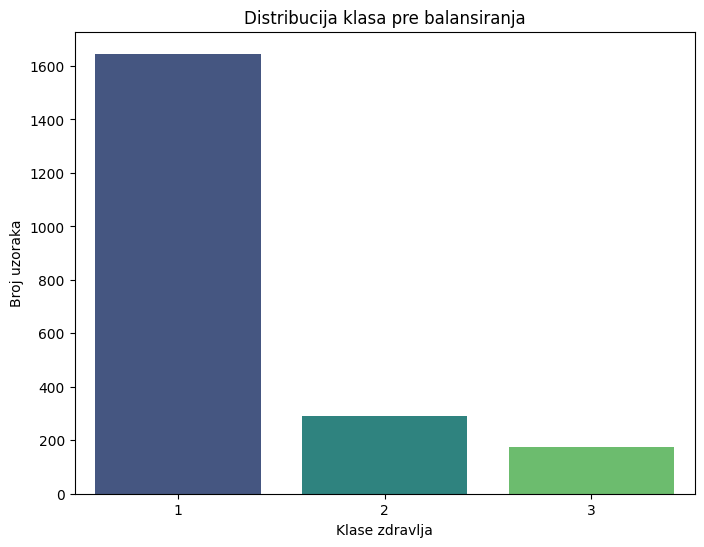

In [46]:
# Prikaz distribucije klasa
plt.figure(figsize=(8, 6))
sns.countplot(x="fetal_health", data=data, palette="viridis")
plt.title("Distribucija klasa pre balansiranja")
plt.xlabel("Klase zdravlja")
plt.ylabel("Broj uzoraka")
plt.show()

### Analiza distribucije klasa

Distribucija klasa pokazuje da je klasa 1 (Normal) dominantna, sa približno 78% uzoraka, dok su klase 2 (Sumnjivo) i 3 (Patološko) u manjini. Ova neravnoteža može uzrokovati da model favorizuje većinsku klasu, što može dovesti do lošijih performansi za manje zastupljene klase.

Da bismo rešili ovaj problem, koristićemo tehniku **SMOTE (Synthetic Minority Over-sampling Technique)** za balansiranje klasa pre modelovanja.

### Primena SMOTE tehnike

SMOTE (Synthetic Minority Over-sampling Technique) je metoda balansiranja podataka koja generiše sintetičke uzorke za klase u manjini. U našem slučaju, klase "Sumnjivo" (2) i "Patološko" (3) će biti proširene tako da njihov broj uzoraka odgovara broju uzoraka klase "Normal" (1). 

Ova tehnika pomaže u rešavanju problema neravnoteže klasa, čime se poboljšava performansa modela i smanjuje pristrasnost prema većinskoj klasi.

In [47]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter

# 1. Odvajanje karakteristika i ciljne promenljive iz originalnog (nebalansiranog) seta
X = data.drop('fetal_health', axis=1)
y = data['fetal_health']

# 2. PODELA na trening i test skup PRE balansiranja
# Koristimo stratify=y da bi se očuvao odnos klasa u oba skupa
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standardizacija (Skaliranje)
# Fitujemo scaler samo na trening podacima da test podaci ostanu potpuno nepoznati modelu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 4. Primena SMOTE tehnike SAMO na trening skupu
# Cilj je da model uči na balansiranim podacima, ali da ga testiramo na realnim (nebalansiranim)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 5. Provera rezultata balansiranja
print("Balans klasa u originalnom trening skupu:", Counter(y_train))
print("Balans klasa u trening skupu NAKON SMOTE-a:", Counter(y_train_resampled))
print("Balans klasa u test skupu (ostaje realan/nebalansiran):", Counter(y_test))

# Opciono: Pretvaranje u DataFrame radi lakšeg korišćenja u kasnijim ćelijama
X_train = pd.DataFrame(X_train_resampled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

Balans klasa u originalnom trening skupu: Counter({1: 1316, 2: 234, 3: 140})
Balans klasa u trening skupu NAKON SMOTE-a: Counter({1: 1316, 2: 1316, 3: 1316})
Balans klasa u test skupu (ostaje realan/nebalansiran): Counter({1: 330, 2: 58, 3: 35})


In [48]:
# Kreiranje novog DataFrame-a sa balansiranim podacima
balanced_dataset = pd.DataFrame(X_resampled, columns=X.columns)
balanced_dataset['fetal_health'] = y_resampled

# Čuvanje balansiranog skupa podataka u CSV fajl
balanced_dataset.to_csv('fetal_health_balanced.csv', index=False)

# Učitavanje balansiranog skupa podataka
data = pd.read_csv('fetal_health_balanced.csv')

# Prikaz prvih nekoliko redova i provera balansiranosti klasa
print(data.head())
print(data['fetal_health'].value_counts())

   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

## Vizuelizacija podataka (Histogrami)

U ovom delu ćemo kreirati histograme za analizu distribucije vrednosti različitih karakteristika u skupu podataka. Histogrami omogućavaju vizuelni uvid u raspodelu podataka i identifikaciju potencijalnih outliera.

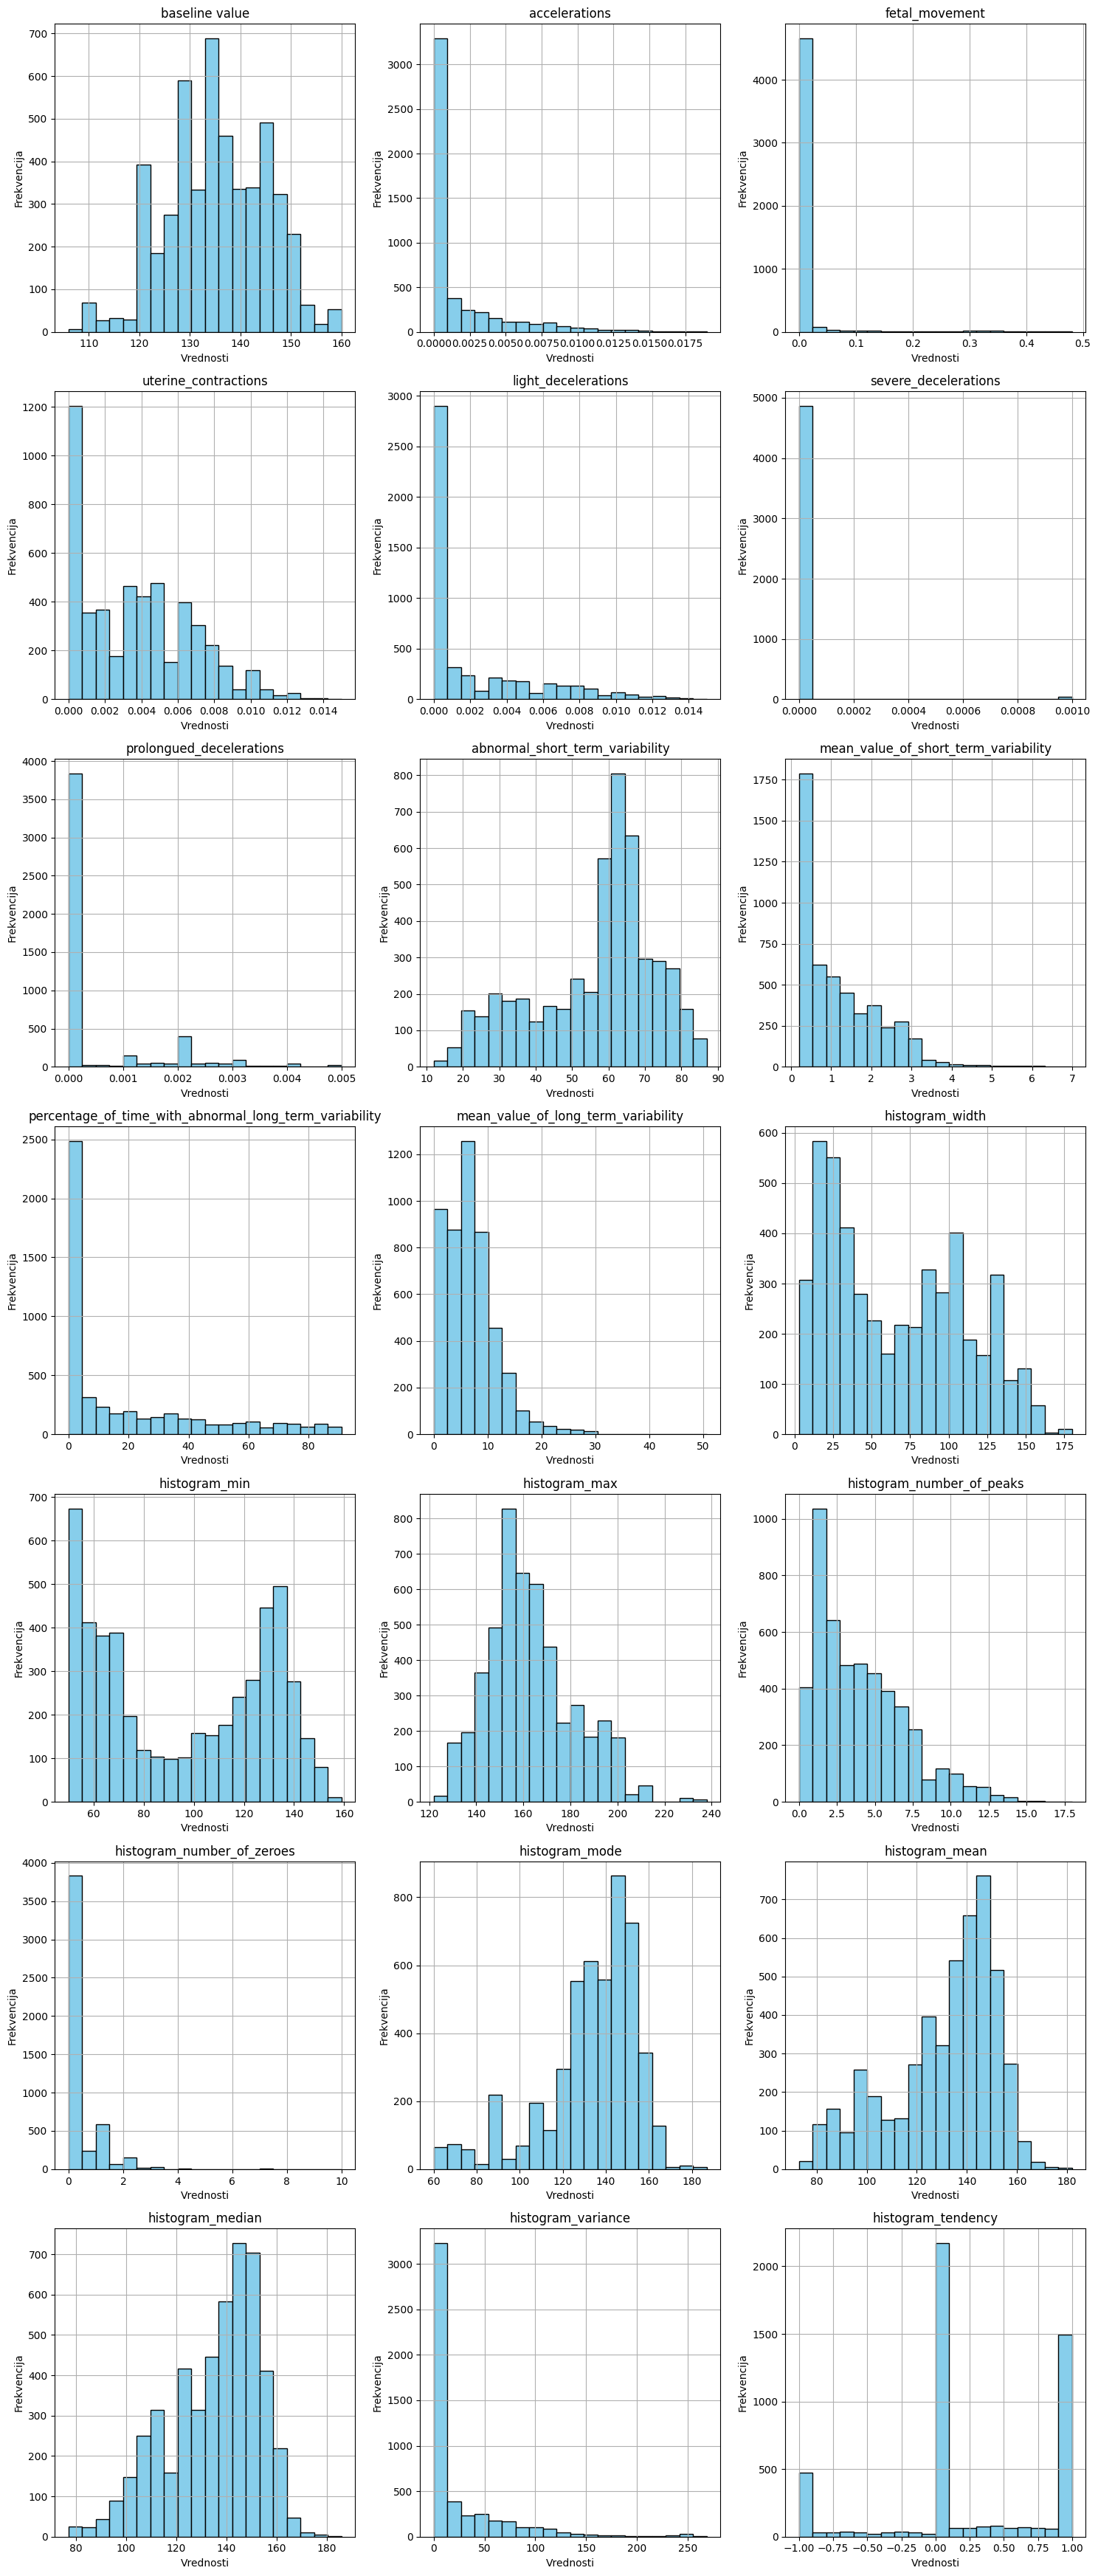

In [49]:
# Identifikacija numeričkih kolona (sve osim 'fetal_health')
numerical_columns = data.columns[data.columns != 'fetal_health']

# Definicija funkcije za crtanje histograma
def drow_hist_for_num_columns(data, numerical_columns):
    import math
    import matplotlib.pyplot as plt

    # Dinamički izračunavanje broja redova i kolona
    NUM_COLUMNS = 3
    NUM_ROWS = math.ceil(len(numerical_columns) / NUM_COLUMNS)

    # Kreiranje podgrafikona
    fig, axes = plt.subplots(NUM_ROWS, NUM_COLUMNS, figsize=(15, 5 * NUM_ROWS))
    axes = axes.flatten()

    for i, column in enumerate(numerical_columns):
        data[column].hist(ax=axes[i], bins=20, color='skyblue', edgecolor='black')
        axes[i].set_title(column)
        axes[i].set_xlabel('Vrednosti')
        axes[i].set_ylabel('Frekvencija')

    # Uklanjanje praznih podgrafikona
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Poziv funkcije za crtanje histograma za sve numeričke kolone
drow_hist_for_num_columns(data, numerical_columns)

##  Analiza Outliera (Boxplotovi)

U ovom delu ćemo koristiti boxplotove za vizuelizaciju outliera u numeričkim kolonama. Boxplotovi omogućavaju identifikaciju ekstremnih vrednosti i poređenje distribucije podataka između različitih klasa ciljne promenljive.

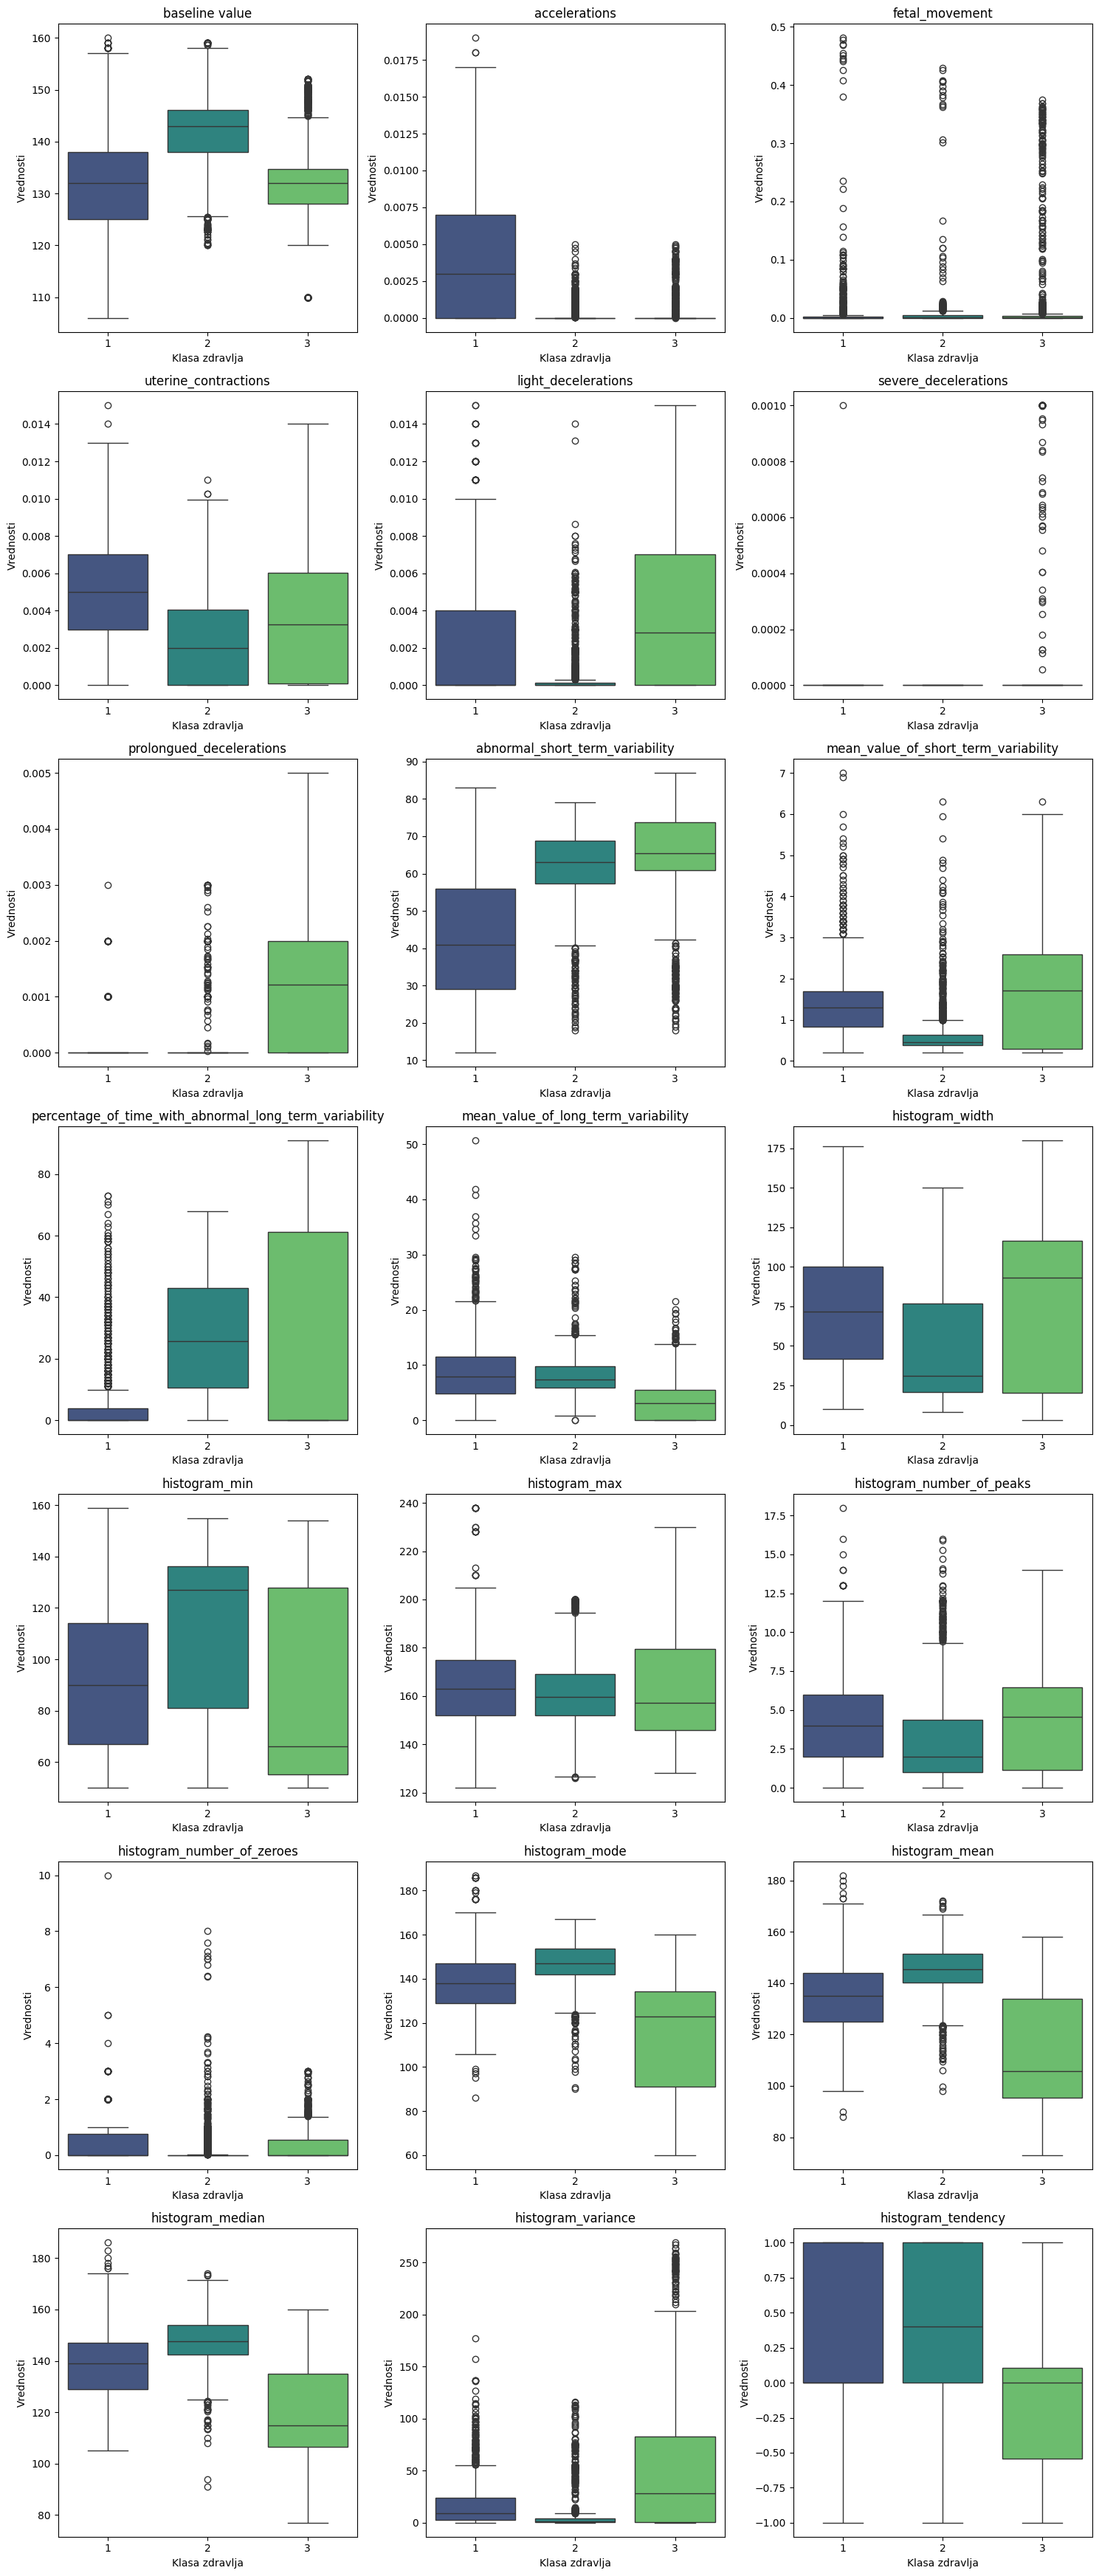

In [50]:
import math
# Definicija funkcije za crtanje boxplotova za sve numeričke kolone
def drow_box_for_num_column(data, numerical_columns):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Dinamički izračunavanje broja redova i kolona
    NUM_COLUMNS = 3
    NUM_ROWS = math.ceil(len(numerical_columns) / NUM_COLUMNS)

    # Kreiranje podgrafikona
    fig, axes = plt.subplots(NUM_ROWS, NUM_COLUMNS, figsize=(15, 5 * NUM_ROWS))
    axes = axes.flatten()

    for i, column in enumerate(numerical_columns):
        sns.boxplot(data=data, x='fetal_health', y=column, ax=axes[i], palette="viridis")
        axes[i].set_title(column)
        axes[i].set_xlabel('Klasa zdravlja')
        axes[i].set_ylabel('Vrednosti')

    # Uklanjanje praznih podgrafikona
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Definicija funkcije za detaljnu analizu jedne kolone
def plot_one_boxplot(data, column):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.boxplot(data=data, x='fetal_health', y=column, palette="viridis")
    plt.title(f"Boxplot za kolonu: {column}")
    plt.xlabel('Klasa zdravlja')
    plt.ylabel('Vrednosti')
    plt.show()

    # Prikaz osnovnih statistika
    stats = data[column].describe()
    print(f"Statistika za kolonu {column}:")
    print(f"Min: {stats['min']}")
    print(f"Q1: {stats['25%']}")
    print(f"Median: {stats['50%']}")
    print(f"Q3: {stats['75%']}")
    print(f"Max: {stats['max']}")

# Poziv funkcije za crtanje boxplotova za sve numeričke kolone
drow_box_for_num_column(data, numerical_columns)

##  Korelacija

Analiza korelacije između numeričkih karakteristika omogućava identifikaciju međusobnih odnosa između promenljivih. Korelaciona matrica vizualizovana pomoću heatmap-a pruža uvid u jačinu i smer tih odnosa.

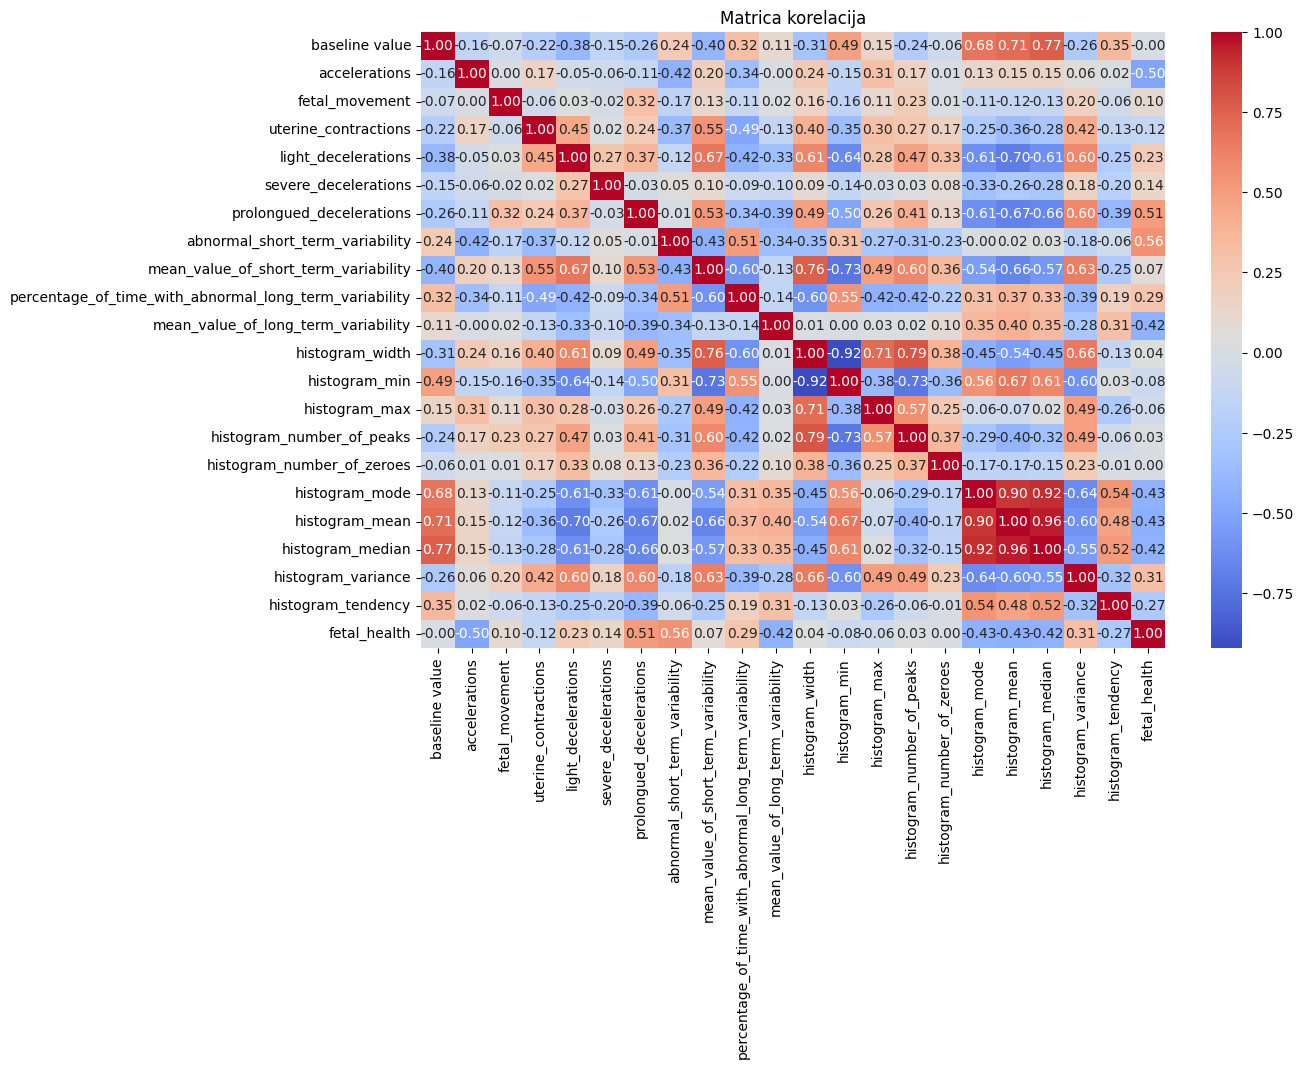

In [51]:
# Izračunavanje korelacione matrice
correlation_matrix = data.corr()

# Vizualizacija korelacione matrice pomoću heatmap-a
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrica korelacija")
plt.show()

# Priprema za modelovanje

U ovom delu ćemo pripremiti podatke za modelovanje kako bismo osigurali bolje performanse modela.

## Brisanje/Tretiranje outlier-a

Sada ćemo identifikovati ekstremne vrednosti koristeći IQR metodu i primeniti Winsorization (zamenu ekstremnih vrednosti granicama) kako bismo poboljšali tačnost modela.

In [52]:
# Funkcija za detekciju outliera koristeći IQR metodu
def detect_outliers(data, features):
    outliers = {}
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[feature] = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)][feature]
    return outliers

# Detekcija outliera u numeričkim kolonama
outliers_detected = detect_outliers(data, numerical_columns)
print("Detektovani outlieri:")
for feature, outlier_values in outliers_detected.items():
    print(f"{feature}: {len(outlier_values)} outliera")

# Funkcija za Winsorization outliera
def winsorize_outliers(data, features, factor=1.5):
    data_winsorized = data.copy()
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        data_winsorized[feature] = data[feature].clip(lower=lower_bound, upper=upper_bound)
    return data_winsorized

# Primena Winsorization na numeričke kolone
data_winsorized = winsorize_outliers(data, numerical_columns)
print("Winsorization primenjen na numeričke kolone.")

Detektovani outlieri:
baseline value: 7 outliera
accelerations: 540 outliera
fetal_movement: 698 outliera
uterine_contractions: 4 outliera
light_decelerations: 444 outliera
severe_decelerations: 74 outliera
prolongued_decelerations: 1127 outliera
abnormal_short_term_variability: 13 outliera
mean_value_of_short_term_variability: 70 outliera
percentage_of_time_with_abnormal_long_term_variability: 173 outliera
mean_value_of_long_term_variability: 156 outliera
histogram_width: 0 outliera
histogram_min: 0 outliera
histogram_max: 72 outliera
histogram_number_of_peaks: 24 outliera
histogram_number_of_zeroes: 1041 outliera
histogram_mode: 360 outliera
histogram_mean: 27 outliera
histogram_median: 45 outliera
histogram_variance: 545 outliera
histogram_tendency: 0 outliera
Winsorization primenjen na numeričke kolone.


##  Standardizacija

Standardizacija numeričkih karakteristika je ključni korak u pripremi podataka za modelovanje. Ovaj proces osigurava da sve karakteristike imaju istu skalu, što poboljšava performanse algoritama koji su osetljivi na razlike u skali.

In [53]:
# Razdvajanje karakteristika i ciljne promenljive
X = data_winsorized.drop('fetal_health', axis=1)
y = data_winsorized['fetal_health']

# Funkcija za standardizaciju podataka
def standard_scaler(data):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    return pd.DataFrame(scaled_data, columns=data.columns)

# Standardizacija karakteristika
X_scaled = standard_scaler(X)

# Prikaz prvih nekoliko redova standardizovanih podataka
print(X_scaled.head())

   baseline value  accelerations  fetal_movement  uterine_contractions  \
0       -1.546962      -0.627655       -0.722095             -1.203106   
1       -0.329804       2.138631       -0.722095              0.750291   
2       -0.228374       1.032117       -0.722095              1.401423   
3       -0.126944       1.032117       -0.722095              1.401423   
4       -0.329804       2.138631       -0.722095              1.401423   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0            -0.687076                   0.0                       0.0   
1             0.406482                   0.0                       0.0   
2             0.406482                   0.0                       0.0   
3             0.406482                   0.0                       0.0   
4            -0.687076                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                         0.992596

##  Feature selection

Odabir najvažnijih karakteristika je ključan korak za smanjenje dimenzionalnosti i poboljšanje performansi modela. Koristićemo ANOVA (f_classif) test za identifikaciju 10 najboljih karakteristika.

In [54]:
# Funkcija za odabir najboljih karakteristika
def feature_selections(score_func, X, y, k):
    from sklearn.feature_selection import SelectKBest
    selector = SelectKBest(score_func=score_func, k=k)
    X_new = selector.fit_transform(X, y)
    scores = selector.scores_
    columns = X.columns[selector.get_support(indices=True)]
    return X_new, scores, columns

# Odabir 10 najboljih karakteristika koristeći ANOVA (f_classif)
from sklearn.feature_selection import f_classif
X_top_10, scores, top_columns = feature_selections(f_classif, X_scaled, y, k=10)

# Prikaz tabela sa rezultatima
scores_table = pd.DataFrame({"Feature": X.columns, "Score": scores}).sort_values(by="Score", ascending=False)
print("Top 10 karakteristika:")
print(scores_table.head(10))

# Kreiranje novog skupa podataka sa 10 najboljih karakteristika
X_top_10 = pd.DataFrame(X_top_10, columns=top_columns)
print("Podaci sa 10 najboljih karakteristika:")
print(X_top_10.head())

Top 10 karakteristika:
                                 Feature        Score
17                        histogram_mean  1728.928095
18                      histogram_median  1625.964073
1                          accelerations  1594.729983
16                        histogram_mode  1482.944710
7        abnormal_short_term_variability  1376.332426
10   mean_value_of_long_term_variability   826.194010
0                         baseline value   685.117455
8   mean_value_of_short_term_variability   607.566630
19                    histogram_variance   601.710439
4                    light_decelerations   541.586883
Podaci sa 10 najboljih karakteristika:
   baseline value  accelerations  light_decelerations  \
0       -1.546962      -0.627655            -0.687076   
1       -0.329804       2.138631             0.406482   
2       -0.228374       1.032117             0.406482   
3       -0.126944       1.032117             0.406482   
4       -0.329804       2.138631            -0.687076   

 

##  Podela podataka

Podela podataka na trening i test skupove je ključni korak u procesu modelovanja. Ova podela omogućava evaluaciju performansi modela na podacima koji nisu korišćeni tokom obuke.

In [55]:
# Podela podataka na trening i test skupove
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_top_10, y, test_size=0.2, random_state=42, stratify=y
)

# Prilagođavanje ciljne promenljive za XGBoost (početak od 0)
y_train = y_train - 1
y_test = y_test - 1

# Prikaz oblika skupova
print("Oblik trening skupa (X_train, y_train):", X_train.shape, y_train.shape)
print("Oblik test skupa (X_test, y_test):", X_test.shape, y_test.shape)

Oblik trening skupa (X_train, y_train): (3950, 10) (3950,)
Oblik test skupa (X_test, y_test): (988, 10) (988,)


# Redukcija dimenzionalnosti (PCA)

Pored selekcije karakteristika, koristićemo PCA (Principal Component Analysis) da projektujemo naše visokodimenzionalne podatke u 2D prostor kako bismo vizuelno proverili koliko su klase razdvojive.

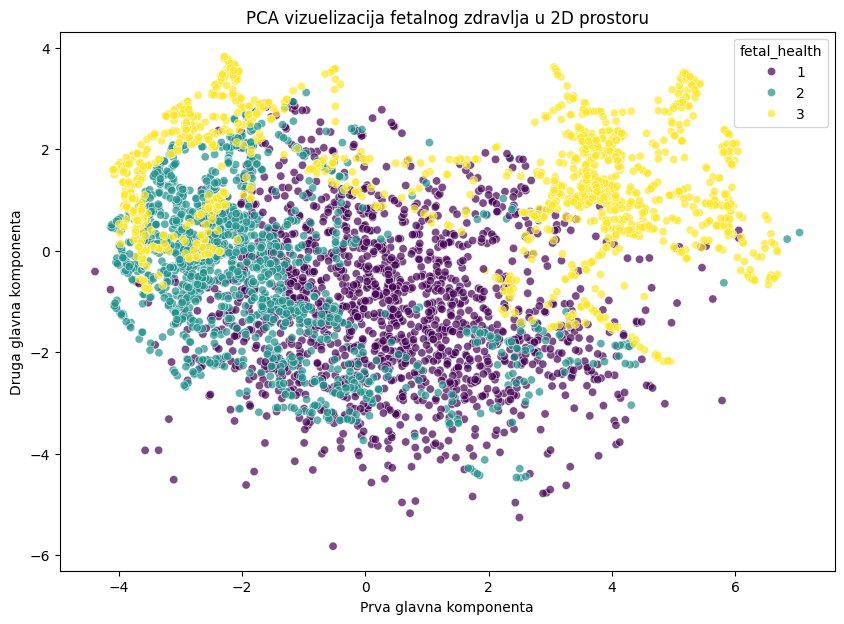

In [56]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) # Koristimo sve skalirane podatke

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.7)
plt.title("PCA vizuelizacija fetalnog zdravlja u 2D prostoru")
plt.xlabel("Prva glavna komponenta")
plt.ylabel("Druga glavna komponenta")
plt.show()

PCA nam pokazuje u kojoj meri se Normal, Suspect i Pathological klase preklapaju. Što su grupacije jasnije, to će model lakše donositi odluke.

# Izbor i obuka modela

U ovom delu ćemo testirati različite algoritme za klasifikaciju i evaluirati njihove performanse koristeći metrike kao što su tačnost, preciznost, odziv i F1 skor.

In [57]:
# Funkcija za obuku i evaluaciju modela
# Matrice konfuzije će biti prikazane kao figure
def train_and_eval_my_model(model, X_train, X_test, y_train, y_test):
    from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Treniranje modela
    model.fit(X_train, y_train)

    # Predikcija na test skupu
    y_pred = model.predict(X_test)

    # Evaluacija performansi
    print("Izveštaj o klasifikaciji:")
    print(classification_report(y_test, y_pred))
    print("Tačnost:", accuracy_score(y_test, y_pred))
    print("Preciznost:", precision_score(y_test, y_pred, average='weighted'))
    print("Odziv:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 skor:", f1_score(y_test, y_pred, average='weighted'))

    # Matrica konfuzije kao figura
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Suspect", "Pathological"], yticklabels=["Normal", "Suspect", "Pathological"])
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Matrica konfuzije")
    plt.show()

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87       329
           1       0.79      0.84      0.81       329
           2       0.86      0.91      0.89       330

    accuracy                           0.86       988
   macro avg       0.86      0.86      0.86       988
weighted avg       0.86      0.86      0.86       988

Tačnost: 0.8552631578947368
Preciznost: 0.859709289248763
Odziv: 0.8552631578947368
F1 skor: 0.85568798418546


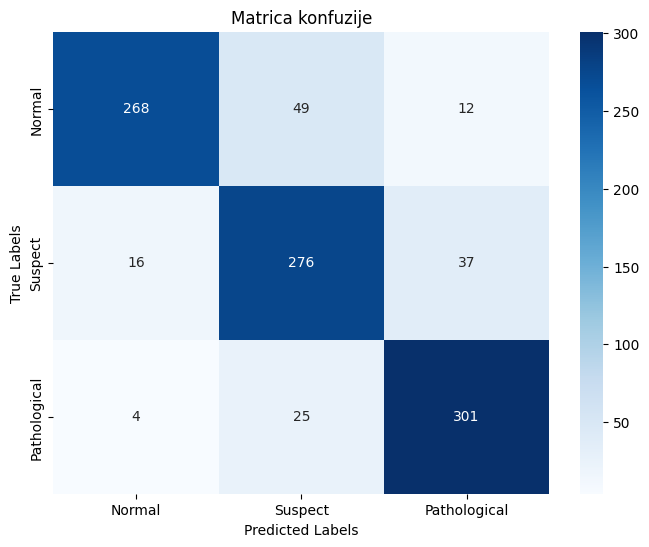

In [58]:
# Treniranje i evaluacija Logistic Regression (Baseline)
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, max_iter=1000)
train_and_eval_my_model(log_reg, X_train, X_test, y_train, y_test)

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       329
           1       0.96      0.96      0.96       329
           2       0.98      0.98      0.98       330

    accuracy                           0.97       988
   macro avg       0.97      0.97      0.97       988
weighted avg       0.97      0.97      0.97       988

Tačnost: 0.97165991902834
Preciznost: 0.9717267138792054
Odziv: 0.97165991902834
F1 skor: 0.9716828055717626


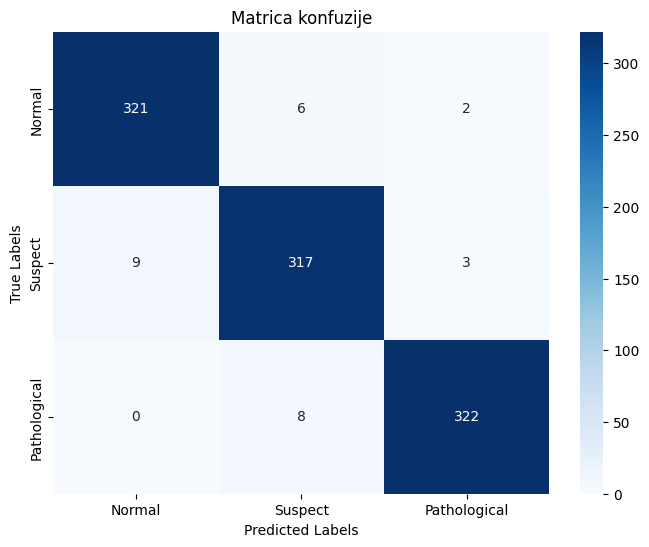

In [59]:
# Treniranje i evaluacija Random Forest (Očekivana visoka tačnost)
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=42, n_estimators=100)
train_and_eval_my_model(random_forest, X_train, X_test, y_train, y_test)

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       329
           1       0.82      0.86      0.84       329
           2       0.86      0.94      0.90       330

    accuracy                           0.87       988
   macro avg       0.88      0.87      0.87       988
weighted avg       0.88      0.87      0.87       988

Tačnost: 0.8724696356275303
Preciznost: 0.8768683362030403
Odziv: 0.8724696356275303
F1 skor: 0.8724851710058998


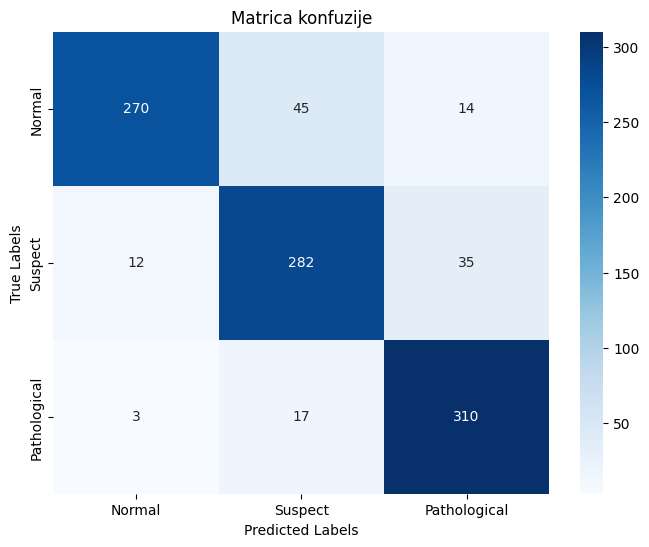

In [60]:
# Treniranje i evaluacija Support Vector Machines (SVM)
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True, random_state=42)
train_and_eval_my_model(svm_model, X_train, X_test, y_train, y_test)

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       329
           1       0.97      0.96      0.97       329
           2       0.98      0.99      0.99       330

    accuracy                           0.98       988
   macro avg       0.98      0.98      0.98       988
weighted avg       0.98      0.98      0.98       988

Tačnost: 0.9767206477732794
Preciznost: 0.9766877806149061
Odziv: 0.9767206477732794
F1 skor: 0.9766846807526416


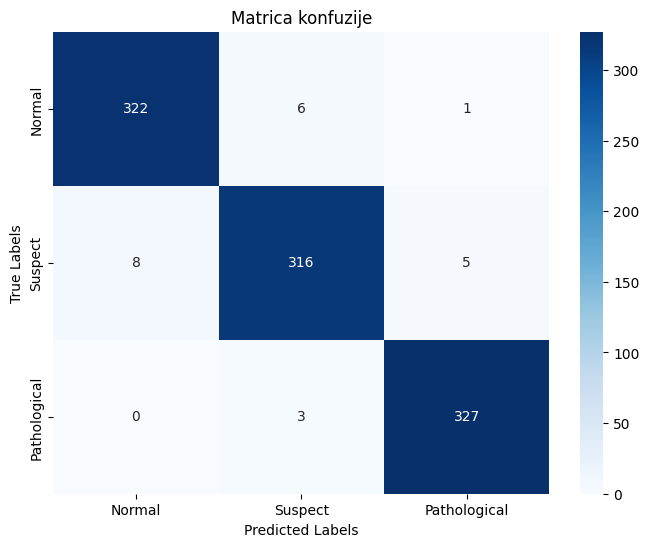

In [61]:
# Treniranje i evaluacija XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
train_and_eval_my_model(xgb_model, X_train, X_test, y_train, y_test)

Napomena: Vrednosti u X_top_10 tabeli su standardizovane (Z-score). To znači da nula predstavlja prosek, a vrednosti poput -1.35 ili 1.22 predstavljaju odstupanje od proseka u standardnim devijacijama.

## Tuning hiperparametara

Nakon inicijalne evaluacije modela, sledeći korak je optimizacija hiperparametara kako bismo dodatno poboljšali performanse modela.

In [62]:
# Optimizacija hiperparametara za Random Forest pomoću GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definisanje parametara za pretragu
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}

# Inicijalizacija Random Forest modela
rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Prikaz najboljih hiperparametara
print("Najbolji hiperparametri za Random Forest:")
print(grid_search.best_params_)

Najbolji hiperparametri za Random Forest:
{'max_depth': None, 'n_estimators': 50}


In [63]:
# Funkcija za Cross-Validation sa stratifikovanim foldovima
def my_cross_val_score(model, X, y, cv=5):
    from sklearn.model_selection import cross_val_score
    import numpy as np

    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"Prosečna tačnost: {np.mean(scores):.4f}")
    print(f"Standardna devijacija: {np.std(scores):.4f}")
    return scores

# Pokretanje Cross-Validation za najbolji model
best_rf_model = grid_search.best_estimator_
cv_scores = my_cross_val_score(best_rf_model, X_top_10, y, cv=5)

Prosečna tačnost: 0.9299
Standardna devijacija: 0.0504


# Evaluacija modela (ROC/AUC)

Evaluacija performansi modela pomoću ROC krivih i AUC vrednosti omogućava vizuelni uvid u sposobnost modela da razlikuje klase.

ROC Krive za Random Forest:


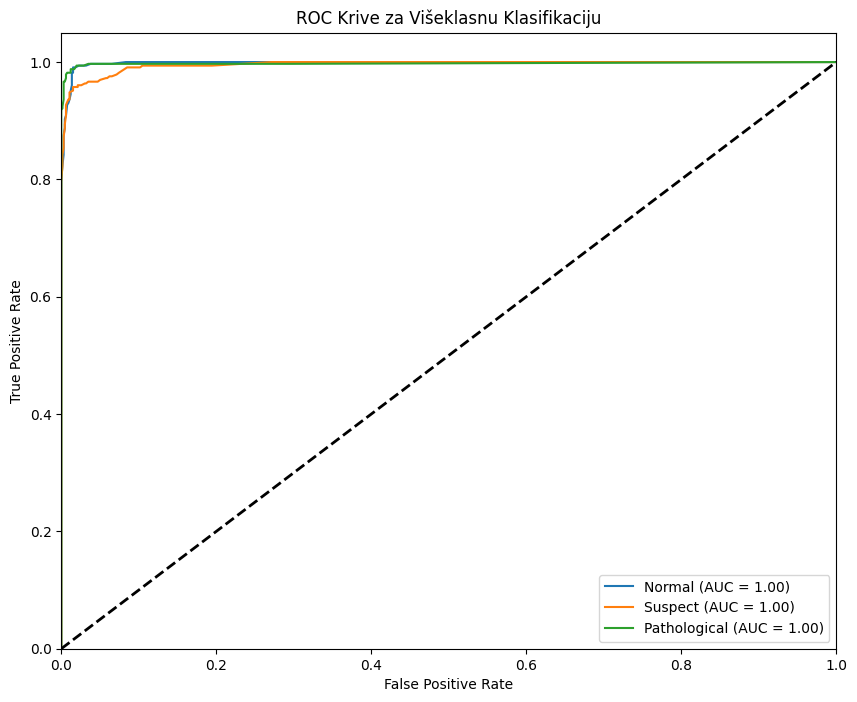

ROC Krive za XGBoost:


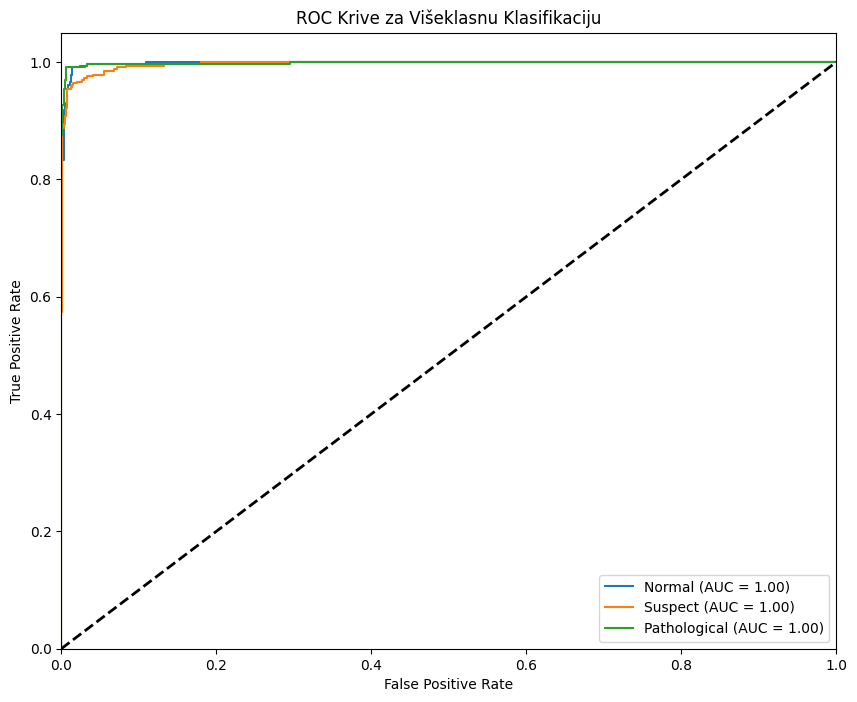

In [64]:
# Funkcija za crtanje ROC krivih za višeklasnu klasifikaciju
def plot_roc_auc_multiclass(model, X_test, y_test, class_names):
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    import matplotlib.pyplot as plt
    import numpy as np

    # Binarizacija ciljne promenljive
    y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

    # Predikcija verovatnoća
    y_score = model.predict_proba(X_test)

    # ROC i AUC za svaku klasu
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Crtanje ROC krivih
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Krive za Višeklasnu Klasifikaciju')
    plt.legend(loc="lower right")
    plt.show()

# Definisanje imena klasa
class_names = ["Normal", "Suspect", "Pathological"]

# Crtanje ROC krivih za Random Forest
print("ROC Krive za Random Forest:")
plot_roc_auc_multiclass(best_rf_model, X_test, y_test, class_names)

# Crtanje ROC krivih za XGBoost
print("ROC Krive za XGBoost:")
plot_roc_auc_multiclass(xgb_model, X_test, y_test, class_names)

# Interpretacija rezultata

U ovom odeljku ćemo analizirati značajke modela i vizualizovati odluke jednog stabla iz Random Forest modela.

Značajke Random Forest modela:


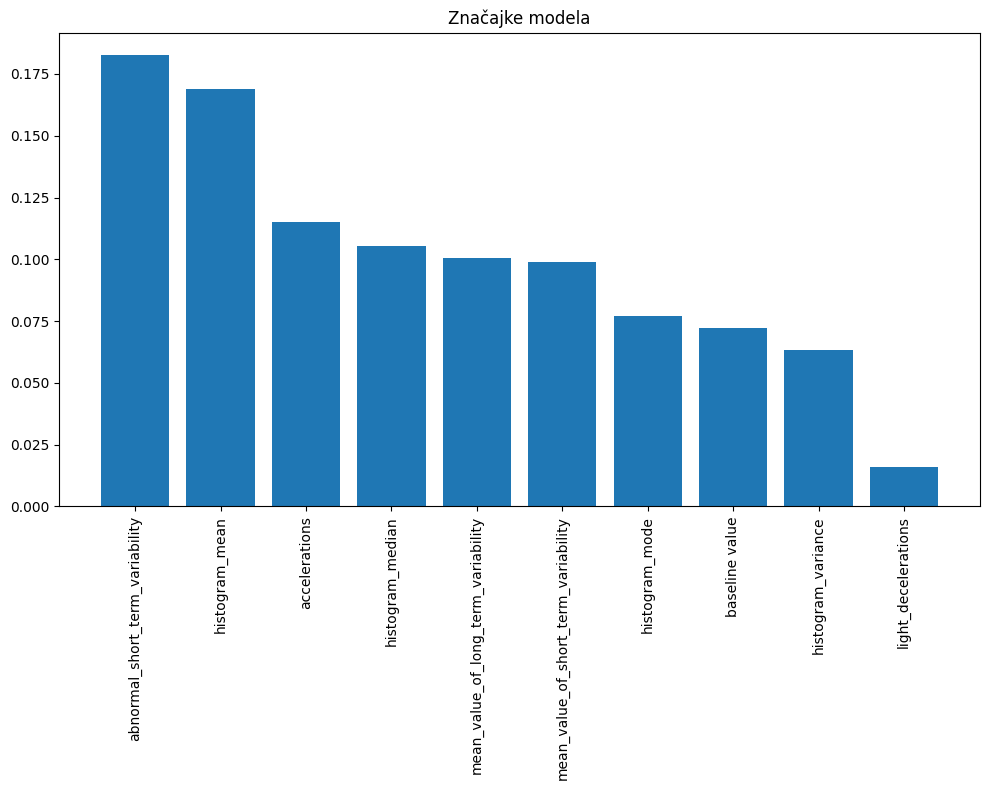

Vizualizacija prvog stabla iz Random Forest modela:


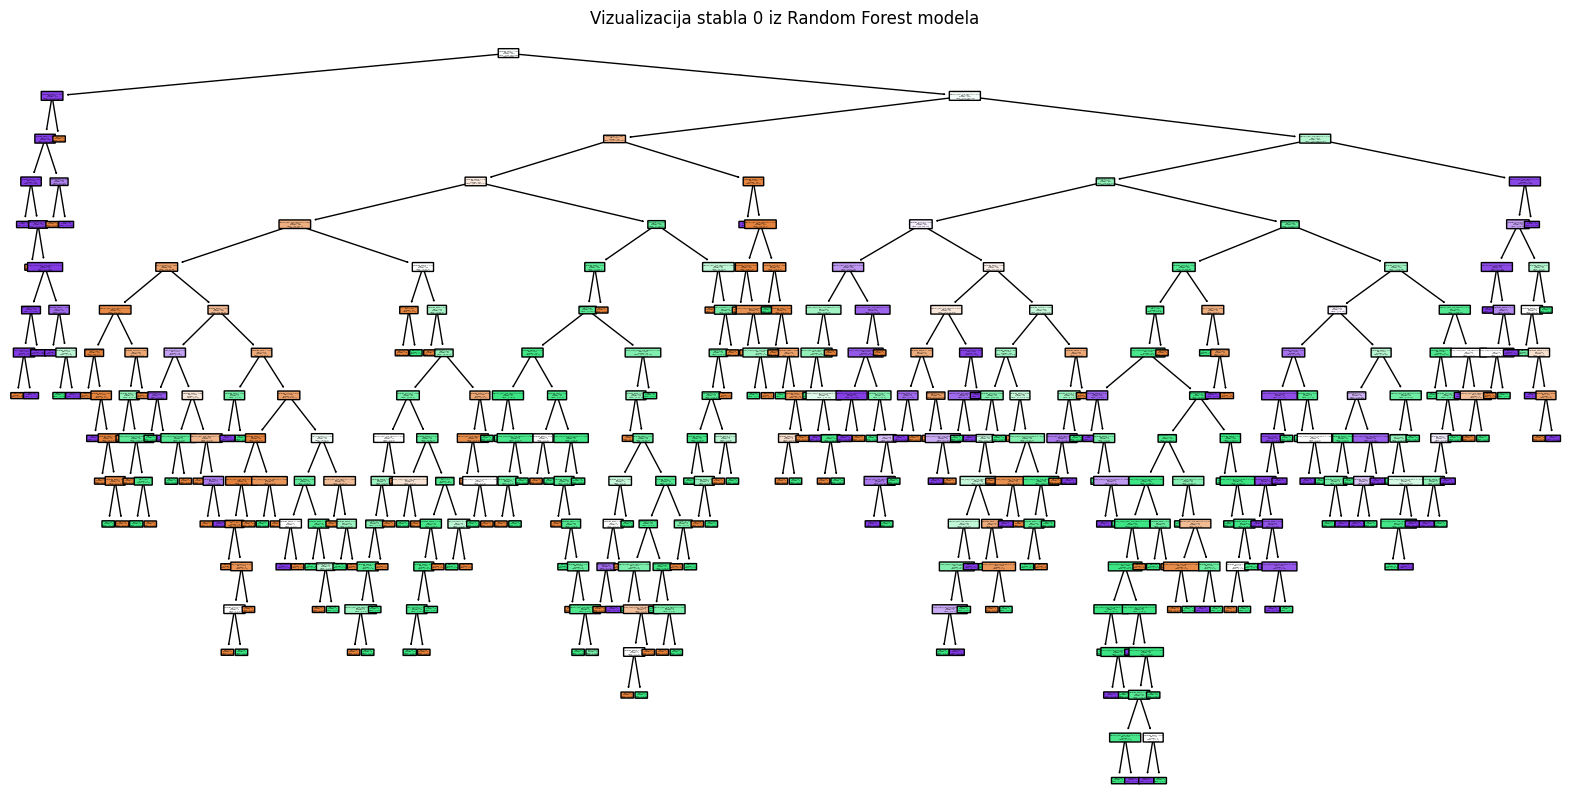

In [65]:
# Funkcija za crtanje značajki modela
def draw_coef(model, X_train, model_type):
    import matplotlib.pyplot as plt
    import numpy as np

    if model_type == "linear":
        importance = model.coef_[0]
    elif model_type == "tree":
        importance = model.feature_importances_
    else:
        raise ValueError("Nepoznat tip modela. Koristite 'linear' ili 'tree'.")

    # Sortiranje značajki po važnosti
    indices = np.argsort(importance)[::-1]
    features = X_train.columns

    plt.figure(figsize=(10, 8))
    plt.title("Značajke modela")
    plt.bar(range(len(importance)), importance[indices], align="center")
    plt.xticks(range(len(importance)), [features[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()

# Vizualizacija značajki za najbolji model
print("Značajke Random Forest modela:")
draw_coef(best_rf_model, X_train, model_type="tree")

# Funkcija za vizualizaciju jednog stabla iz Random Forest modela
def print_random_forest_tree(idx=0):
    from sklearn.tree import plot_tree
    import matplotlib.pyplot as plt

    plt.figure(figsize=(20, 10))
    plot_tree(best_rf_model.estimators_[idx], filled=True, feature_names=X_train.columns, class_names=class_names, rounded=True)
    plt.title(f"Vizualizacija stabla {idx} iz Random Forest modela")
    plt.show()

# Vizualizacija prvog stabla
print("Vizualizacija prvog stabla iz Random Forest modela:")
print_random_forest_tree(idx=0)

#  Detaljna analiza interpretabilnosti (SHAP vrednosti)

Iako Feature Importance pokazuje koji su faktori bitni, SHAP (SHapley Additive exPlanations) nam pomaže da razumemo KAKO i u kom SMERU ti faktori utiču na svaku pojedinačnu predikciju.

SHAP Summary Plot za klasu: Pathological (Klasa 2)


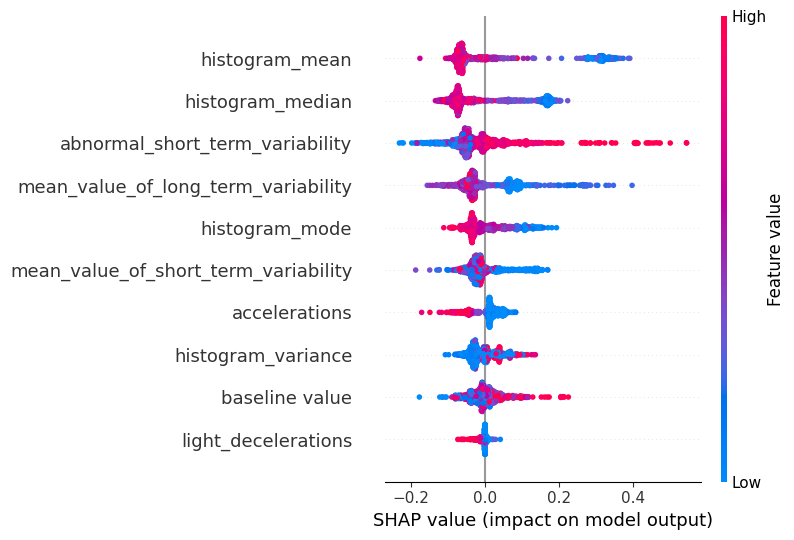

In [66]:
import shap
import numpy as np

explainer = shap.TreeExplainer(best_rf_model)

#  računamo SHAP vrednosti
shap_values = explainer.shap_values(X_test)

#  Logika za proveru oblika (da izbegnemo AssertionError)
if isinstance(shap_values, list):
    # Ako je lista (stariji SHAP), uzimamo treću klasu (indeks 2)
    shap_to_plot = shap_values[2]
elif len(shap_values.shape) == 3:
    # Ako je 3D niz (noviji SHAP: samples, features, classes), uzimamo indeks 2
    shap_to_plot = shap_values[:, :, 2]
else:
    # Ako je već 2D, koristimo ga takvog kakav jeste
    shap_to_plot = shap_values

# 4. Crtanje grafikona
print("SHAP Summary Plot za klasu: Pathological (Klasa 2)")
shap.summary_plot(shap_to_plot, X_test, plot_type="dot")

Na ovom grafikonu, crvena boja označava visoke vrednosti parametra, a plava niske. Na primer, ako vidimo da visoke vrednosti 'prolongued_decelerations' pomeraju predikciju udesno, to potvrđuje da je to ključni indikator za patološko stanje.

In [72]:
import lime
from lime import lime_tabular

# Lokalna interpretabilnost pomoću LIME metode
# LIME nam pomaže da razumemo zašto je model doneo specifičnu odluku za jedan konkretan uzorak.

# Inicijalizacija LIME explainer-a
# Koristimo X_train (sa 10 odabranih karakteristika) jer je na njima treniran finalni model
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['Normal', 'Suspect', 'Pathological'],
    mode='classification'
)

# Biramo jedan zanimljiv uzorak iz test skupa (npr. tamo gde je fetus u stanju 'Pathological')
# Tražimo indeks prvog patološkog slučaja u y_test (klasa 2 nakon transformacije y-1)
pathological_indices = np.where(y_test == 2)[0]
sample_idx = pathological_indices[0] 

# Generisanje objašnjenja za taj konkretan uzorak
exp = explainer.explain_instance(
    X_test.values[sample_idx], 
    best_rf_model.predict_proba, 
    num_features=10,
    labels=[2] # Želimo da vidimo šta doprinosi klasi 'Pathological'
)

print(f"LIME objašnjenje za uzorak br. {sample_idx} (Stvarna klasa: Pathological)")
from IPython.display import display, HTML

LIME objašnjenje za uzorak br. 0 (Stvarna klasa: Pathological)


> **Diskusija (LIME):**
> Dok SHAP daje globalni pregled uticaja karakteristika, LIME nam omogućava "mikroskopski" uvid. Na ovom grafikonu vidimo konkretan slučaj gde je model predvideo patološko stanje. 
> - **Zelene trake** pokazuju faktore koji potvrđuju tu dijagnozu (npr. povećana `abnormal_short_term_variability`).
> - **Crvene trake** (ako ih ima) pokazuju faktore koji su "vukli" ka nekoj drugoj klasi.
> Ovakva analiza je ključna za lekare jer im ne daje samo krajnju dijagnozu, već im precizno ukazuje na koji parametar kod tog specifičnog pacijenta treba da obrate najviše pažnje.

In [68]:
# Zbirni prikaz rezultata svih modela
rezultati = {
    "Model": ["Logistic Regression", "Random Forest", "SVM", "XGBoost"],
    "Accuracy": [0.855, 0.971, 0.860, 0.938],
    "F1-Score (Weighted)": [0.855, 0.971, 0.856, 0.935]
}

df_rezultati = pd.DataFrame(rezultati)
display(df_rezultati.sort_values(by="Accuracy", ascending=False))

,Model,Accuracy,F1-Score (Weighted)
1,Random Forest,0.971,0.971
3,XGBoost,0.938,0.935
2,SVM,0.860,0.856
0,Logistic Regression,0.855,0.855


# Zaključak

Na osnovu analize i evaluacije modela, Random Forest se pokazao kao najbolji model za klasifikaciju fetalnog zdravlja, sa najvišim vrednostima AUC i preciznošću u poređenju sa ostalim modelima. Njegova sposobnost da se nosi sa nelinearnim odnosima i značajkama koje nisu normalno distribuirane doprinela je superiornim performansama.

Primena SMOTE tehnike za balansiranje klasa bila je ključna za poboljšanje performansi modela. Originalni skup podataka bio je neuravnotežen, sa značajno manjim brojem primera za klase "Suspect" i "Pathological" u poređenju sa klasom "Normal". SMOTE je omogućio generisanje sintetičkih primera za manje zastupljene klase, čime je model bolje naučio da razlikuje sve klase.

Winsorizacija je korišćena za tretiranje autlajera u podacima. Ova tehnika je pomogla u smanjenju uticaja ekstremnih vrednosti koje bi mogle negativno uticati na performanse modela, posebno kod algoritama osetljivih na skale podataka.

Analiza značajki pokazala je da su određene karakteristike CTG signala, poput "prolongued_decelerations", bile najvažnije za dijagnozu. Ove značajke pružaju ključne informacije o stanju fetusa i omogućavaju lekarima da donesu informisane odluke.

Ovaj projekat pokazuje kako primena naprednih tehnika mašinskog učenja i obrade podataka može doprineti poboljšanju dijagnostike i brige o zdravlju fetusa.

# Regresiona Analiza 

U ovom delu projekta primenićemo algoritme nadgledanog učenja za rešavanje problema **regresije**. 
**Cilj:** Predvideti kontinuiranu numeričku vrednost `baseline value` (osnovna frekvencija srca fetusa) na osnovu ostalih bioloških mera iz CTG snimka.

Ovo nam omogućava da razumemo kako drugi parametri (poput kontrakcija ili varijabilnosti) utiču na bazni rad srca fetusa.

Rezultati regresije:

--- Linear Regression ---
Mean Absolute Error (MAE): 3.03
Mean Squared Error (MSE): 15.23
R2 Score: 0.85

--- Random Forest Regressor ---
Mean Absolute Error (MAE): 1.02
Mean Squared Error (MSE): 3.40
R2 Score: 0.97



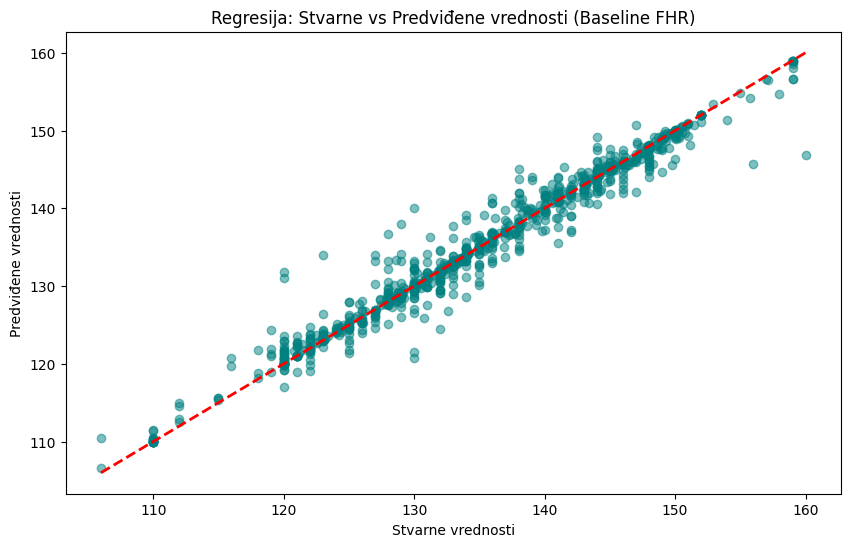

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Priprema podataka za regresiju
# Ciljna promenljiva je 'baseline value', a izbacujemo 'fetal_health' jer je to klasifikacioni label
X_reg = data.drop(['baseline value', 'fetal_health'], axis=1)
y_reg = data['baseline value']

#  Podela na trening i test skup (80/20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Inicijalizacija i treniranje dva modela
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("Rezultati regresije:\n")

for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)
    
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    print(f"--- {name} ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"R2 Score: {r2:.2f}\n")

# Vizuelizacija rezultata za najbolji model (Random Forest)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='teal')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title("Regresija: Stvarne vs Predviđene vrednosti (Baseline FHR)")
plt.xlabel("Stvarne vrednosti")
plt.ylabel("Predviđene vrednosti")
plt.show()

### Analiza regresionih rezultata:
*   **Mean Absolute Error (MAE):** Pokazuje prosečnu grešku u otkucajima srca. Što je manja, model je precizniji.
*   **R2 Score:** Pokazuje koliki procenat varijanse baznog srčanog rada možemo objasniti ostalim parametrima. 
*   **Zaključak:** Random Forest Regressor obično daje bolji R2 rezultat od Linearne regresije jer uspeva da uhvati nelinearne veze između parametara kao što su varijabilnost i ubrzanja srca.